# Partnership Lead Insights – Business Development Project

This project was a part of my **Business Development internship**, where I focused on turning raw lead data into **actionable insights** for partnerships and growth strategy.  

## 🎯 Objective
To analyze partnership leads and create a **lead prioritization framework** that helps Business Development teams:  
- Identify high-value leads  
- Understand lead distribution by region and deal size  
- Optimize outreach strategies  

## 🛠️ Approach
1. **Data Cleaning** – removed duplicates, filled missing values, and standardized key fields.  
2. **Exploratory Analysis** – studied leads by deal size, country, and source.  
3. **Lead Scoring Model** – designed a simple scoring logic based on:  
   - Potential deal size (Small/Medium/Large)  
   - Territory/Region (APAC, EMEA, NA)  
   - Lead Source (Web, Trade Show, etc.)  
4. **Visualization** – created charts to highlight trends and top opportunities.  



## 📊 Key Insights
- **Deal Size Distribution:** Majority of leads are concentrated in *medium* deals, with fewer large opportunities.  
- **Regional Patterns:** Top 10 countries contribute to the bulk of partnership opportunities.  
- **Lead Sources:** Certain channels (e.g., trade shows, web) bring higher-quality leads.  
- **Lead Scoring:** Enabled ranking of leads to highlight the top 20% worth pursuing.  

---

## 💡 Business Impact
- Helped prioritize outreach efforts for the BD team.  
- Improved efficiency by highlighting **where to focus resources**.  
- Provided a scalable framework for evaluating new leads in the future.  

---

## 🌱 Takeaway
Business Development is not just about chasing every lead — it’s about **using insights to focus on the right opportunities**.  
This project shows how **data + strategy** can work together to build smarter BD processes.  


In [3]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn

In [5]:
#reading data and cleaning
df = pd.read_csv('C:/Users/Kamakshi/Downloads/archive (12)/fake_lead_data.csv', encoding="latin1")

df = df.drop_duplicates()
df = df.dropna(subset = ["CUSTOMERNAME", "COUNTRY", "POTENTIALDEALSIZE"])

In [7]:
#summarizing
print("Shape:", df.shape)
print(df.head())

Shape: (1221, 12)
               CUSTOMERNAME             PHONE                   ADDRESSLINE1  \
0         Land of Toys Inc.        2125557818        897 Long Airport Avenue   
1        Reims Collectables        26.47.1555             59 rue de l'Abbaye   
2           Lyon Souveniers  +33 1 46 62 7555  27 rue du Colonel Pierre Avia   
3         Toys4GrownUps.com        6265557265             78934 Hillside Dr.   
4  Corporate Gift Ideas Co.        6505551386                7734 Strong St.   

            CITY STATE POSTALCODE COUNTRY TERRITORY CONTACTLASTNAME  \
0            NYC    NY      10022     USA       NaN             NaN   
1          Reims   NaN      51100  France      EMEA             NaN   
2          Paris   NaN      75508  France      EMEA             NaN   
3       Pasadena    CA      90003     USA       NaN             NaN   
4  San Francisco    CA        NaN     USA       NaN             NaN   

  CONTACTFIRSTNAME POTENTIALDEALSIZE  LEADSOURCE  
0             Kwai     

C:\Users\Kamakshi\AppData\Local\Temp\ipykernel_40028\1007838498.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.countplot(data = df, x = "POTENTIALDEALSIZE", palette = "viridis")


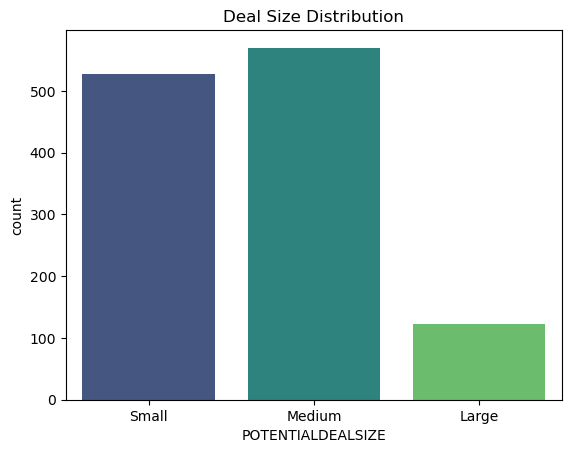

In [9]:
#performing basic eda
#1. deal size distribution
sn.countplot(data = df, x = "POTENTIALDEALSIZE", palette = "viridis")
plt.title("Deal Size Distribution")
plt.show()

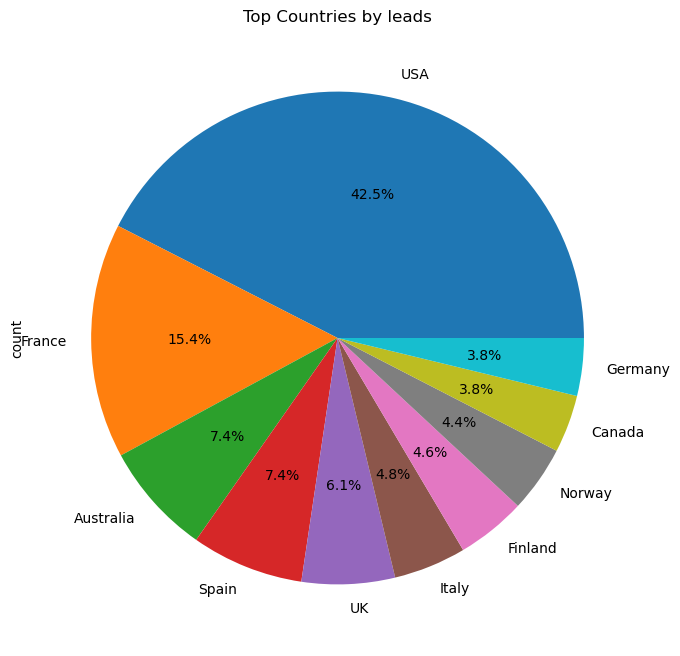

In [17]:
#2. leabds by country
top_countries = df["COUNTRY"].value_counts().head(10)
top_countries.plot(kind="pie", autopct='%1.1f%%', figsize=(10,8), title = "Top Countries by leads")
plt.show()

C:\Users\Kamakshi\AppData\Local\Temp\ipykernel_40028\4092168514.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.boxplot(data=df, x="POTENTIALDEALSIZE", y="LEAD_SCORE", palette="coolwarm")


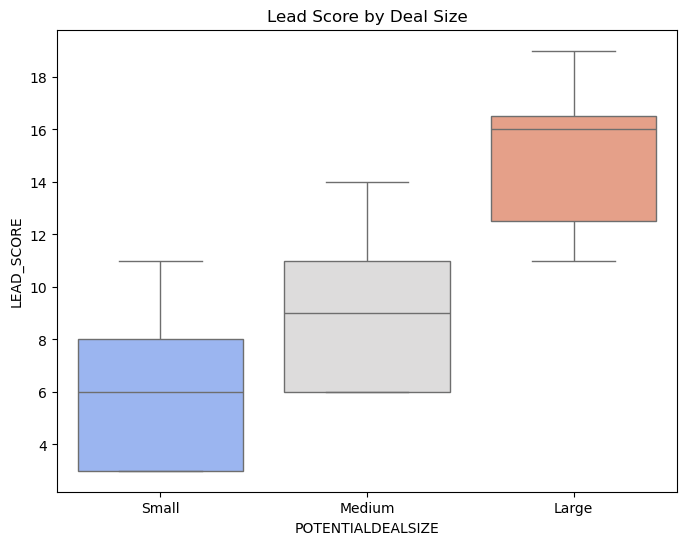

In [27]:
plt.figure(figsize=(8,6))
sn.boxplot(data=df, x="POTENTIALDEALSIZE", y="LEAD_SCORE", palette="coolwarm")
plt.title("Lead Score by Deal Size")
plt.show()

C:\Users\Kamakshi\AppData\Local\Temp\ipykernel_40028\1022168013.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sn.barplot(data=df[df["COUNTRY"].isin(top_countries)], x="COUNTRY", y="LEAD_SCORE", palette="viridis")


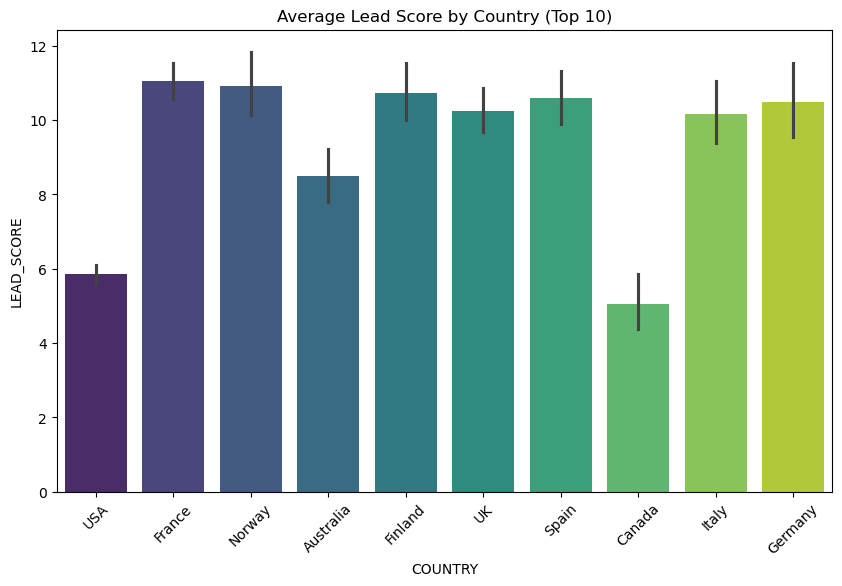

In [47]:
# 3. Lead Score by Country / Territory
if "COUNTRY" in df.columns:
    plt.figure(figsize=(10,6))
    top_countries = df["COUNTRY"].value_counts().head(10).index
    sn.barplot(data=df[df["COUNTRY"].isin(top_countries)], x="COUNTRY", y="LEAD_SCORE", palette="viridis")
    plt.title("Average Lead Score by Country (Top 10)")
    plt.xticks(rotation=45)
    plt.show()

In [21]:
# 5. Lead Scoring (Rule-based)
def score_lead(row):
    score = 0
    # Deal size
    if str(row["POTENTIALDEALSIZE"]).strip().lower()== "large":
        score += 10
    elif str(row["POTENTIALDEALSIZE"]).strip().lower() == "medium":
        score += 5
    elif str(row["POTENTIALDEALSIZE"]).strip().lower() == "small":
        score += 2
    
    # Territory weight (fill NaN with 'Unknown')
    territory = str(row["TERRITORY"]).strip().upper()
    if territory == "EMEA":
        score += 5
    elif territory == "APAC":
        score += 3
    elif territory in ["NA", "NORTH AMERICA"]:
        score += 4
    
    # Lead source (fill NaN with 'other')
    source = str(row["LEADSOURCE"]).strip().lower()
    if source == "trade show":
        score += 4
    elif source == "web":
        score += 3
    else:
        score += 1
    
    return score

In [23]:
df["LEAD_SCORE"] = df.apply(score_lead, axis=1)
print(df["LEAD_SCORE"].describe())   # quick check

count    1221.000000
mean        8.402129
std         3.806762
min         3.000000
25%         6.000000
50%         8.000000
75%        11.000000
max        19.000000
Name: LEAD_SCORE, dtype: float64


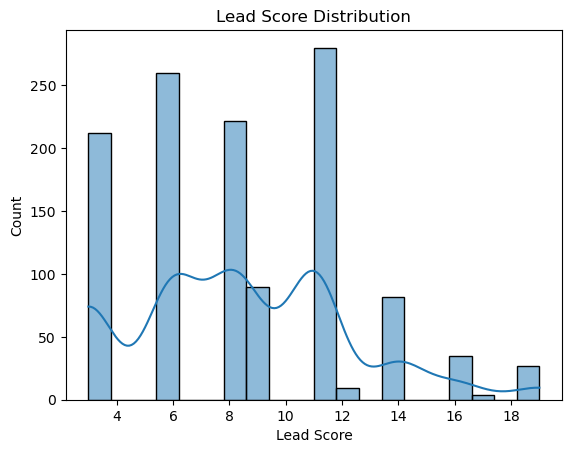

In [25]:
#visual of same
sn.histplot(df["LEAD_SCORE"], bins=20, kde=True)
plt.title("Lead Score Distribution")
plt.xlabel("Lead Score")
plt.ylabel("Count")
plt.show()